![PNS](http://caillau.perso.math.cnrs.fr/logo-pns.png)
## MAM5-INUM - Commande optimale
# TP 2 - Tir simple

On considère le problème de contrôle optimal suivant :

$$ \frac{1}{2} \int_0^1 |u(t)|^2\,\mathrm{d}t \to \min $$

sous les contraintes

$$ \dot{x}(t) = -x(t)+u(t),\quad u(t) \in \mathbf{R},\quad t \in [0,1],\\
   x(0)=-1,\quad x(1)=0. $$

Résoudre le problème numériquement à l'aide d'une méthode de tir.

In [5]:
# Flow
using Zygote, OrdinaryDiffEq

function Flow(h)

    function hv(t, x, p)
        foo = (x, p) -> h(t, x, p)
        dhdx, dhdp = Zygote.gradient(foo, x, p)
        return [ dhdp ; -dhdx ]
    end

    function rhs!(dz, z, dummy, t)
        n = size(z, 1)÷2
        dz[:] = hv(t, z[1:n], z[n+1:2*n])
    end
    
    function f(tspan, x0, p0; abstol=1e-12, reltol=1e-12, saveat=[])
        z0 = [ x0 ; p0 ]
        ode = ODEProblem(rhs!, z0, tspan)
        sol = solve(ode, Tsit5(), abstol=abstol, reltol=reltol, saveat=saveat)
        return sol
    end
    
    function f(t0, x0, p0, tf; abstol=1e-12, reltol=1e-12, saveat=[])
        sol = f((t0, tf), x0, p0, abstol=abstol, reltol=reltol, saveat=saveat)
        n = size(x0, 1)
        return sol[1:n, end], sol[n+1:2*n, end]
    end
    
    return f

end

Flow (generic function with 1 method)

In [6]:
using ForwardDiff, NLsolve, LinearAlgebra, Plots

t0 = 0.
tf = 1.
x0 = [ -1. ]
xf_fixed = [ 0. ] # target

# Hamiltonian
function h(t, x, p)
    r = p[1]^2/2-p[1]*x[1]
    return r
end

# Makes flow from Hamiltonian
f = Flow(h)

# Shooting function
function shoot(p0)
    xf, pf = f(t0, x0, p0, tf)
    s = xf - xf_fixed
    return s
end

shoot (generic function with 1 method)

In [7]:
# Solve
jshoot  = p0 -> ForwardDiff.jacobian(shoot, p0)

p0_guess = [ 2. ] # initial guess
sol = nlsolve(shoot, jshoot, p0_guess; xtol=1e-8, method=:trust_region, show_trace=true); println(sol)
if converged(sol)
    p0 = sol.zero
else
    error("Not converged")
end

Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------
     0     1.982523e+00              NaN
     1     7.533684e-15     1.686965e+00
Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [2.0]
 * Zero: [0.3130352854993397]
 * Inf-norm of residuals: 0.000000
 * Iterations: 1
 * Convergence: true
   * |x - x'| < 1.0e-08: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 2
 * Jacobian Calls (df/dx): 2


1-element Vector{Float64}:
 0.3130352854993397

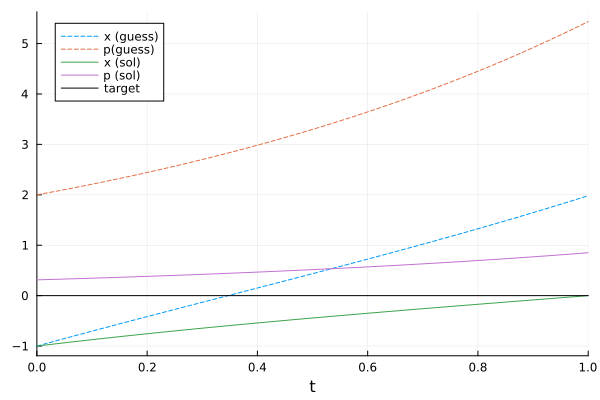

In [8]:
# Plots
guess = f((t0, tf), x0, p0_guess)
fig1 = plot(guess, xlabel="t", label=[ "x (guess)" "p(guess)" ], linestyle=:dash)
sol = f((t0, tf), x0, p0)
plot!(fig1, sol, label=[ "x (sol)" "p (sol)"], linestyle=:solid)
plot!(fig1, [ t0, tf ], [ xf_fixed[1], xf_fixed[1] ], label="target", colour=:black)